In [205]:
import rasterio
import rasterio.features
import numpy as np
import pandas as pd
from pathlib import Path
import geopandas as gpd
from datetime import datetime
import matplotlib.pyplot as plt

In [206]:
def find_all_data_files(data_type, base_path = "../../data", resolution = "10m"):
    """
    Discover all {data_type} {resolution} files across all seasons
    Returns: Dictionary {season: {date: file_path}}
    """
    seasons = {}
    
    # Navigate through each season folder
    for season_folder in ['2022_2023', '2023_2024', '2024_2025']:
        season_path = Path(base_path) / season_folder / data_type / resolution
        
        # Find all {resolution} files
        files = season_path.glob(f"{data_type}_Tokara_*_{resolution}.tif")
        
        # Extract dates
        data_dict = {}
        for file_path in files:
            # Extract date from filename
            date_str = file_path.stem.split('_')[2]
            
            data_dict[date_str] = file_path
        
        seasons[season_folder] = data_dict
    
    # Report findings
    for season, files in seasons.items():
        print(f"{season}: {len(files)} {data_type} files found")
        print(f"  Date range: {min(files.keys())} to {max(files.keys())}")
    
    return seasons

seasons_ETa_dict = find_all_data_files(data_type="ETa")
seasons_NDVI_dict = find_all_data_files(data_type="NDVI")
seasons_ETo_dict = find_all_data_files(data_type="ETo")

2022_2023: 261 ETa files found
  Date range: 2022-08-13 to 2023-04-30
2023_2024: 272 ETa files found
  Date range: 2023-08-03 to 2024-04-30
2024_2025: 262 ETa files found
  Date range: 2024-08-12 to 2025-04-30
2022_2023: 36 NDVI files found
  Date range: 2022-08-13 to 2023-04-30
2023_2024: 34 NDVI files found
  Date range: 2023-08-03 to 2024-04-29
2024_2025: 31 NDVI files found
  Date range: 2024-08-12 to 2025-04-24
2022_2023: 273 ETo files found
  Date range: 2022-08-01 to 2023-04-30
2023_2024: 274 ETo files found
  Date range: 2023-08-01 to 2024-04-30
2024_2025: 273 ETo files found
  Date range: 2024-08-01 to 2025-04-30


Data Analysis

In [207]:
def date_coverage(seasons_dict):

    #Check which dates have ETa data vs. which are missing

    for season, eta_files in seasons_dict.items():
        # Expected date range for this season
        start_date = datetime.strptime(min(eta_files.keys()), '%Y-%m-%d')
        end_date = datetime.strptime(max(eta_files.keys()), '%Y-%m-%d')
        
        all_dates = pd.date_range(start_date, end_date, freq='D')
        
        # Check which dates are missing
        eta_dates = set(eta_files.keys())

        missing_dates = []
        
        for date in all_dates:
            date_str = date.strftime('%Y-%m-%d')
            if date_str not in eta_dates:
                missing_dates.append(date_str)
        
        print(f"\n{season}:")
        print(f"  Start: {start_date.strftime('%Y-%m-%d')}")
        print(f"  End: {end_date.strftime('%Y-%m-%d')}")
        print(f"  Total days in range: {len(all_dates)}")
        print(f"  Days with data: {len(eta_dates)}")
        print(f"  Missing days: {len(missing_dates)}")
        
        if len(missing_dates) <= 10:
            print(f"  Missing dates: {missing_dates}")

print("ETa date coverage:")
date_coverage(seasons_ETa_dict)

print("ETo date coverage:")
date_coverage(seasons_ETo_dict)

print("NDVI date coverage:")
date_coverage(seasons_NDVI_dict)

ETa date coverage:

2022_2023:
  Start: 2022-08-13
  End: 2023-04-30
  Total days in range: 261
  Days with data: 261
  Missing days: 0
  Missing dates: []

2023_2024:
  Start: 2023-08-03
  End: 2024-04-30
  Total days in range: 272
  Days with data: 272
  Missing days: 0
  Missing dates: []

2024_2025:
  Start: 2024-08-12
  End: 2025-04-30
  Total days in range: 262
  Days with data: 262
  Missing days: 0
  Missing dates: []
ETo date coverage:

2022_2023:
  Start: 2022-08-01
  End: 2023-04-30
  Total days in range: 273
  Days with data: 273
  Missing days: 0
  Missing dates: []

2023_2024:
  Start: 2023-08-01
  End: 2024-04-30
  Total days in range: 274
  Days with data: 274
  Missing days: 0
  Missing dates: []

2024_2025:
  Start: 2024-08-01
  End: 2025-04-30
  Total days in range: 273
  Days with data: 273
  Missing days: 0
  Missing dates: []
NDVI date coverage:

2022_2023:
  Start: 2022-08-13
  End: 2023-04-30
  Total days in range: 261
  Days with data: 36
  Missing days: 225

2

From the dataset we have there are no missing dates

In [208]:
#Reading the shapefiles
base_path = Path("../../data")
shapefile_path = Path(base_path) / 'Shapefiles' / 'Tokara_Polygons.shp'
blocks = gpd.read_file(shapefile_path)

print("Number of blocks:", len(blocks))
print("\nColumns:", blocks.columns.tolist())
print("\nFirst 5 rows:")
print(blocks.head(20))
print("\nData types:")
print(blocks.dtypes)
print("\nCoordinate system:")
print(blocks.crs)

Number of blocks: 70

Columns: ['CULTIVAR', 'BLOCK', 'SOURCE', 'geometry']

First 5 rows:
             CULTIVAR BLOCK                         SOURCE  \
0            CabFranc    K1             TK_CabFranc_K1.shp   
1            CabFranc   K11            TK_CabFranc_K11.shp   
2            CabFranc   K15            TK_CabFranc_K15.shp   
3   CabernetSauvignon    K1    TK_CabernetSauvignon_K1.shp   
4   CabernetSauvignon   K10   TK_CabernetSauvignon_K10.shp   
5   CabernetSauvignon   K12   TK_CabernetSauvignon_K12.shp   
6   CabernetSauvignon   K13   TK_CabernetSauvignon_K13.shp   
7   CabernetSauvignon   K18   TK_CabernetSauvignon_K18.shp   
8   CabernetSauvignon    K7    TK_CabernetSauvignon_K7.shp   
9   CabernetSauvignon    K9    TK_CabernetSauvignon_K9.shp   
10  CabernetSauvignon    M1    TK_CabernetSauvignon_M1.shp   
11  CabernetSauvignon    M4    TK_CabernetSauvignon_M4.shp   
12  CabernetSauvignon    M5    TK_CabernetSauvignon_M5.shp   
13  CabernetSauvignon   R1b   TK_CabernetS

<Axes: >

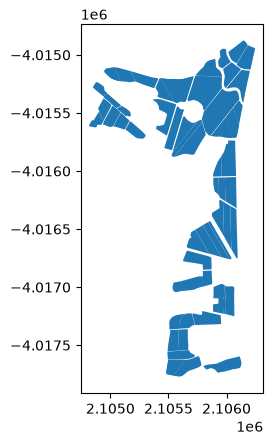

In [209]:
blocks.plot()

In [210]:
type(blocks.geometry[1])
print(blocks.crs)

EPSG:3857


In [211]:
def extract_block_value(raster_file_path, block_index, value_name):
    """
    Extract the mean value for a specific block from a raster file.
    Returns: Mean raster value for the block
    """

    with rasterio.open(raster_file_path) as src:
        blocks_utm = blocks.to_crs(src.crs)
        block_polygon = blocks_utm.geometry[block_index]

        raster_data = src.read()
        raster_data = np.reshape(raster_data, raster_data.shape[1:])

        mask = rasterio.features.geometry_mask(
            [block_polygon],
            transform=src.transform,
            invert=True,
            out_shape=raster_data.shape
        )

        block_values = raster_data[mask]
        mean_value = np.nanmean(block_values)

        return mean_value


def extract_block_eta(eta_file_path, block_index):
    """
    Extract ETa value for a specific block from a raster file.
    Returns: ETa value in mm
    """
    return extract_block_value(eta_file_path, block_index, "eta")

def extract_block_eto(eto_file_path, block_index):
    """
    Extract ETo value for a specific block from a raster file.
    Returns: ETo value in mm
    """
    return extract_block_value(eto_file_path, block_index, "eto")


def extract_block_ndvi(ndvi_file_path, block_index):
    """
    Extract NDVI value for a specific block from a raster file.
    Returns: NDVI value
    """
    return extract_block_value(ndvi_file_path, block_index, "ndvi")


def unified_eta_series(seasons_eta_dict, seasons_ndvi_dict):
    """
    Extract ETa and NDVI for a block across all seasons.
    Returns: Multi-index DataFrame (season, date)
    """
    all_data = []
    for block in range(len(blocks)):
        print(f"Processing block {block}...")
        for season, eta_files in seasons_eta_dict.items():
            print(f"Processing {season}...")
            season_data = []
            ndvi_files = seasons_ndvi_dict[season]
            eto_files = seasons_ETo_dict[season]

            for date_str, eta_file_path in sorted(eta_files.items()):
                eta_value = extract_block_eta(eta_file_path, block)

                ndvi_file_path = ndvi_files.get(date_str)
                if ndvi_file_path is not None:
                    ndvi_value = extract_block_ndvi(ndvi_file_path, block)
                else:
                    ndvi_value = np.nan

                eto_file_path = eto_files.get(date_str)
                if eto_file_path is not None:
                    eto_value = extract_block_eto(eto_file_path, block)
                else:
                    eto_value = np.nan

                season_data.append({
                    'date': date_str,
                    'date_dt': datetime.strptime(date_str, '%Y-%m-%d'),
                    'season': season,
                    'block_id': blocks['BLOCK'].iloc[block],
                    'cultivar': blocks['CULTIVAR'].iloc[block],
                    'file': eta_file_path.name,
                    'eta_mm': eta_value,
                    'eto_mm': eto_value,
                    'ndvi': ndvi_value
                })
            
            df = pd.DataFrame(season_data)
            all_data.append(df)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    return combined_df

unified_df = unified_eta_series(seasons_ETa_dict, seasons_NDVI_dict)

Processing block 0...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 1...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 2...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 3...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 4...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 5...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 6...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 7...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 8...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 9...
Processing 2022_2023...
Processing 2023_2024...
Processing 2024_2025...
Processing block 10...
Processing 2022_2023...
Processing 20

In [212]:
unified_df.head(20)

,date,date_dt,season,block_id,cultivar,file,eta_mm,eto_mm,ndvi
0,2022-08-13,2022-08-13,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-13_10m.tif,0.784121,1.705543,0.609871
1,2022-08-14,2022-08-14,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-14_10m.tif,0.648975,1.411602,NaN
2,2022-08-15,2022-08-15,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-15_10m.tif,0.923639,2.008839,NaN
3,2022-08-16,2022-08-16,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-16_10m.tif,1.117947,2.431299,NaN
4,2022-08-17,2022-08-17,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-17_10m.tif,0.440940,0.958794,NaN
5,2022-08-18,2022-08-18,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-18_10m.tif,0.436152,0.948547,NaN
6,2022-08-19,2022-08-19,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-19_10m.tif,0.598839,1.302648,NaN
7,2022-08-20,2022-08-20,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-20_10m.tif,0.740315,1.610280,NaN
8,2022-08-21,2022-08-21,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-21_10m.tif,0.932117,2.027231,NaN
9,2022-08-22,2022-08-22,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-22_10m.tif,1.062577,2.310920,NaN


In [213]:
unified_df['block_id'].unique()

<StringArray>
[  'K1',  'K11',  'K15',  'K10',  'K12',  'K13',  'K18',   'K7',   'K9',
   'M1',   'M4',   'M5',  'R1b',  'R1c',  'R1d',   'R2', 'R4ad',  'R4b',
  'R4c',  'R5a',  'R5b',  'R6c',  'S4a',  'S5a',  'S5b',  'S5c',   'M2',
   'M3',  'R3a',  'R3b',  'R6a',  'R6b',   'R7',   'R8', 'S3ab', 'R10a',
 'R10b', 'R10c',   'K3',   'K4',  'K14',   'K2',   'K8',  'R11',  'R16',
   'S8', 'S4bc',  'R12',  'R13',  'R14',  'R15',   'R9',   'K5',   'K6',
  'R1a',   'S6',   'S7']
Length: 57, dtype: str

In [215]:
#rainfall data extraction from meteorological data

import openmeteo_requests
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"

start_date = unified_df['date'].min()
end_date = unified_df['date'].max()
params = {
	"latitude": -33.9180637, 
	"longitude": 18.9187235,
	"start_date": start_date,
	"end_date": end_date,
	"daily": ["temperature_2m_mean", "rain_sum"],
	"timezone": "auto",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_rain_sum = daily.Variables(1).ValuesAsNumpy()

daily_data = {
	"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["rain_sum"] = daily_rain_sum

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe)


Coordinates: -33.91915512084961°N 18.965087890625°E
Elevation: 377.0 m asl
Timezone: b'Africa/Johannesburg'b'GMT+2'
Timezone difference to GMT+0: 7200s

Daily data
                          date  temperature_2m_mean   rain_sum
0   2022-08-13 00:00:00+02:00             7.102083  14.099999
1   2022-08-14 00:00:00+02:00             7.614583   4.500000
2   2022-08-15 00:00:00+02:00             7.862500   0.000000
3   2022-08-16 00:00:00+02:00            10.837501   0.000000
4   2022-08-17 00:00:00+02:00             9.420834  45.100002
..                        ...                  ...        ...
987 2025-04-26 00:00:00+02:00            20.931250   0.000000
988 2025-04-27 00:00:00+02:00            23.212500   0.000000
989 2025-04-28 00:00:00+02:00            18.172918   0.000000
990 2025-04-29 00:00:00+02:00            14.816667   0.100000
991 2025-04-30 00:00:00+02:00            13.587501   0.300000

[992 rows x 3 columns]


In [216]:

weather_csv_path = Path(base_path) / "historic_weather_data.csv"
eta_csv_path = Path(base_path) / "historic_eta_data.csv"

for csv_path in [weather_csv_path, eta_csv_path]:
    if csv_path.exists():
        csv_path.unlink()
        print(f"Removed existing file: {csv_path}")

# Save the newly generated data
weather_csv_path.write_text("")
daily_dataframe.to_csv(weather_csv_path, index=False)
eta_csv_path.write_text("")
unified_df.to_csv(eta_csv_path, index=False)

print(f"Saved weather data to {weather_csv_path}")
print(f"Saved ETa/NDVI data to {eta_csv_path}")

Removed existing file: ..\..\data\historic_weather_data.csv
Removed existing file: ..\..\data\historic_eta_data.csv
Saved weather data to ..\..\data\historic_weather_data.csv
Saved ETa/NDVI data to ..\..\data\historic_eta_data.csv


## Reading phenology data

In [217]:
phenology_df = pd.read_excel("../../data/Tokara_Pheno_Data.xlsx")

In [218]:
phenology_df['Block ID'].unique()

array(['S3ab', 'M2', 'M3', 'R3a', 'R3b', 7, 8, 'R10a', 'R10b', 'R10c', 9,
       12, 13, 14, 15, 16, 11, 'K2', 'K8', 'K14', 'S4bc', 'R1a', 'K5',
       'K6', 'S6', 'S7', 'K4', 'K3', 'S8', 'K15', 'K11', 'K1', 'K7', 'K9',
       'K10', 'K12', 'K13', 'K18', 'M1', 'M4', 'M5', 'S5a', 'S5b', 'S5c',
       'R1b', 'R1c', 'R1d', 2, 'R4ad', 'R4b', 'R4c', 'R5a', 'R5b', 'S4a'],
      dtype=object)

In [219]:
phenology_df.loc[phenology_df['Block ID'].astype(str).str.startswith(tuple('123456789')), 'Block ID'] = phenology_df.loc[phenology_df['Block ID'].astype(str).str.startswith(tuple('123456789')), 'Block ID'].astype(str).str.replace(r'^(\d+)$', r'R\1', regex=True)

In [220]:
phenology_df['Block ID'].unique()

array(['S3ab', 'M2', 'M3', 'R3a', 'R3b', 'R7', 'R8', 'R10a', 'R10b',
       'R10c', 'R9', 'R12', 'R13', 'R14', 'R15', 'R16', 'R11', 'K2', 'K8',
       'K14', 'S4bc', 'R1a', 'K5', 'K6', 'S6', 'S7', 'K4', 'K3', 'S8',
       'K15', 'K11', 'K1', 'K7', 'K9', 'K10', 'K12', 'K13', 'K18', 'M1',
       'M4', 'M5', 'S5a', 'S5b', 'S5c', 'R1b', 'R1c', 'R1d', 'R2', 'R4ad',
       'R4b', 'R4c', 'R5a', 'R5b', 'S4a'], dtype=object)

In [221]:
phenology_df

,Vineyard_ID,Farm,Cultivar,Block ID,season,Latitude,Longitude,Budbreak,Flowering,PreVeraison,Harvest,Leafdrop
0,TK_Chardonnay_S3ab,Tokara,Chardonnay,S3ab,2022/2023,33.917063°S,18.918652°E,2022-08-19,2022-10-14,NaT,NaT,NaN
1,TK_Chardonnay_M2,Tokara,Chardonnay,M2,2022/2023,33.912681°S,18.918300°E,NaT,NaT,NaT,NaT,NaN
2,TK_Chardonnay_M3,Tokara,Chardonnay,M3,2022/2023,33.912448°S,18.917952°E,2022-08-19,2022-10-14,NaT,NaT,NaN
3,TK_Chardonnay_R3a,Tokara,Chardonnay,R3a,2022/2023,33.907612°S,18.918067°E,2022-09-02,2022-10-14,NaT,NaT,NaN
4,TK_Chardonnay_R3b,Tokara,Chardonnay,R3b,2022/2023,33.907612°S,18.918067°E,2022-09-02,2022-10-14,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
157,TK_CabernetSauvignon_R4b,Tokara,CabernetSauvignon,R4b,2024/2025,33.905877°S,18.918395°E,2024-09-27,2024-11-01,2025-01-14,2025-04-02,NaN
158,TK_CabernetSauvignon_R4c,Tokara,CabernetSauvignon,R4c,2024/2025,33.905896°S,18.919022°E,2024-09-27,2024-11-01,2025-01-14,2025-03-27,NaN
159,TK_CabernetSauvignon_R5a,Tokara,CabernetSauvignon,R5a,2024/2025,33.904633°S,18.917870°E,2024-09-27,2024-11-01,2025-01-14,2025-03-24,NaN
160,TK_CabernetSauvignon_R5b,Tokara,CabernetSauvignon,R5b,2024/2025,33.903905°S,18.918763°E,2024-09-27,2024-11-01,2025-01-14,2025-03-25,NaN


In [222]:
# group data by cultivar and block_id to calculate average days between phenological stages
phenology_df['budbreak_days'] = (phenology_df['Flowering'] - phenology_df['Budbreak'])
phenology_df['flowering_days'] = (phenology_df['PreVeraison'] - phenology_df['Flowering'])
phenology_df['preveraison_days'] = (phenology_df['Harvest'] - phenology_df['PreVeraison'])

grouped_pheno = phenology_df.groupby(['Cultivar', 'Block ID']).agg({
    'budbreak_days': 'mean',
    'flowering_days': 'mean',
    'preveraison_days': 'mean' 
})


In [223]:
grouped_pheno.head()

budbreak_days   flowering_days preveraison_days
Cultivar          Block ID                                                   
CabFranc          K11      53 days 16:00:00 80 days 12:00:00          62 days
                  K15      52 days 12:00:00 80 days 12:00:00          57 days
CabernetSauvignon K1       45 days 12:00:00 73 days 12:00:00          66 days
                  K10      49 days 00:00:00 73 days 12:00:00          80 days
                  K12      49 days 00:00:00 73 days 12:00:00          79 days

In [224]:
unified_df['Vineyard_ID'] = "TK_" + unified_df['cultivar'] + "_" + unified_df['block_id'].astype(str)

In [226]:
merged_df = unified_df.merge(phenology_df[[ 'Vineyard_ID', 'Budbreak', 'Flowering', 'PreVeraison', 'Harvest', 'Leafdrop']], on = ['Vineyard_ID'], how = 'left')
merged_df.sort_values(by=['date'], inplace=True)
merged_df.reset_index(drop=True, inplace=True)

In [227]:
phenology_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   Vineyard_ID       162 non-null    str            
 1   Farm              162 non-null    str            
 2   Cultivar          162 non-null    str            
 3   Block ID          162 non-null    object         
 4   season            162 non-null    str            
 5   Latitude          162 non-null    str            
 6   Longitude         162 non-null    str            
 7   Budbreak          159 non-null    datetime64[us] 
 8   Flowering         144 non-null    datetime64[us] 
 9   PreVeraison       108 non-null    datetime64[us] 
 10  Harvest           54 non-null     datetime64[us] 
 11  Leafdrop          0 non-null      float64        
 12  budbreak_days     144 non-null    timedelta64[us]
 13  flowering_days    108 non-null    timedelta64[us]
 14  preveraison_days  54 

In [228]:
merged_df['Stage'] = ""
for index, row in merged_df.iterrows():
    if row['date_dt'] < row['Flowering']:
        merged_df.at[index, 'Stage'] = 'Budbreak'
    elif row['date_dt'] < row['PreVeraison']:
        merged_df.at[index, 'Stage'] = 'Flowering'
    elif row['date_dt'] < row['Harvest']:
        merged_df.at[index, 'Stage'] = 'PreVeraison'
    elif row['date_dt'] >= row['Harvest']:
        merged_df.at[index, 'Stage'] = 'Harvest'
    else:
        merged_df.at[index, 'Stage'] = np.nan

In [229]:
merged_df

,date,date_dt,season,block_id,cultivar,file,eta_mm,eto_mm,ndvi,Vineyard_ID,Budbreak,Flowering,PreVeraison,Harvest,Leafdrop,Stage
0,2022-08-13,2022-08-13,2022_2023,K1,CabFranc,ETa_Tokara_2022-08-13_10m.tif,0.784121,1.705543,0.609871,TK_CabFranc_K1,NaT,NaT,NaT,NaT,NaN,NaN
1,2022-08-13,2022-08-13,2022_2023,R14,SauvignonBlanc,ETa_Tokara_2022-08-13_10m.tif,-5418.467773,1.644722,-5418.572754,TK_SauvignonBlanc_R14,2023-09-01,2023-11-03,2024-01-08,NaT,NaN,Budbreak
2,2022-08-13,2022-08-13,2022_2023,R14,SauvignonBlanc,ETa_Tokara_2022-08-13_10m.tif,-5418.467773,1.644722,-5418.572754,TK_SauvignonBlanc_R14,2022-09-16,2022-10-28,NaT,NaT,NaN,Budbreak
3,2022-08-13,2022-08-13,2022_2023,R8,Chardonnay,ETa_Tokara_2022-08-13_10m.tif,0.760163,1.668967,0.670831,TK_Chardonnay_R8,2022-09-09,2022-10-21,NaT,NaT,NaN,Budbreak
4,2022-08-13,2022-08-13,2022_2023,R8,Chardonnay,ETa_Tokara_2022-08-13_10m.tif,0.760163,1.668967,0.670831,TK_Chardonnay_R8,2023-08-25,2023-10-27,2024-01-01,NaT,NaN,Budbreak
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141505,2025-04-30,2025-04-30,2024_2025,K4,Malbec,ETa_Tokara_2025-04-30_10m.tif,0.902382,1.789834,NaN,TK_Malbec_K4,2022-09-02,2022-10-21,NaT,NaT,NaN,NaN
141506,2025-04-30,2025-04-30,2024_2025,K3,Malbec,ETa_Tokara_2025-04-30_10m.tif,0.858699,1.778220,NaN,TK_Malbec_K3,NaT,NaT,NaT,NaT,NaN,NaN
141507,2025-04-30,2025-04-30,2024_2025,R8,CheninBlanc,ETa_Tokara_2025-04-30_10m.tif,0.836428,1.752195,NaN,TK_CheninBlanc_R8,NaT,NaT,NaT,NaT,NaN,NaN
141508,2025-04-30,2025-04-30,2024_2025,S6,Shiraz,ETa_Tokara_2025-04-30_10m.tif,0.789448,1.818515,NaN,TK_Shiraz_S6,2024-09-27,2024-11-01,2025-01-14,2025-03-06,NaN,Harvest


In [230]:
#dealing with missing NDVI values by forward filling

merged_df['ndvi'] = merged_df['ndvi'].ffill()
merged_df['Stage'] = merged_df['Stage'].ffill()

In [231]:
merged_df.drop(columns=['Budbreak', 'Flowering', 'PreVeraison', 'Harvest', 'Leafdrop'], inplace=True)

In [236]:
merged_df.groupby(['season']).min()
for season in merged_df['season'].unique():
    season_df = merged_df[merged_df['season'] == season]
    min_date = season_df['date_dt'].min()
    merged_df.loc[merged_df['season'] == season, 'days_since_planting'] = (merged_df.loc[merged_df['season'] == season, 'date_dt'] - min_date).dt.days
merged_df['days_since_planting'] = merged_df['days_since_planting'].astype(int)/100

In [ ]:
merged_df

In [244]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = merged_df[['eto_mm', 'ndvi', 'Stage', 'cultivar', 'season', 'days_since_planting']]
y = merged_df['eta_mm']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_features = ['Stage', 'cultivar', 'season']
numeric_features = ['eto_mm', 'ndvi', 'days_since_planting']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model =Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)

Root Mean Squared Error: 356.0975372983979
R-squared: 0.8981327868552533


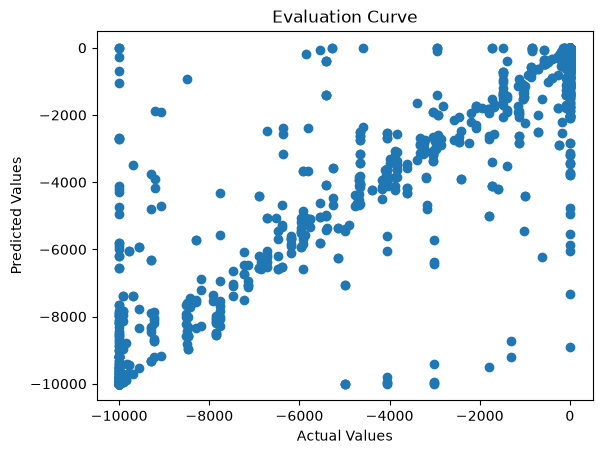

In [246]:
#model evaluation
from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

#evaluation curve
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Evaluation Curve")
plt.show()